TODO:
* sample m-c pairs from the posterior
* generate NFW profiles for those m-c pairs
* compare with the median observed NFW profile
* for a given radial bin, compare the delta sigma values from observation vs from the generated values
* later on, add the error bars so we can see those as well

In [247]:
from sbi.analysis import pairplot
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pickle
import torch
import weaklensclustersbi.simulations.wlprofile as wlprofile

In [248]:
SIM_ID = 'sim_low'
INFER_ID = 'infer_low'
OBS_ID = 'obs_low'
NUM_SIMS = 10000
NUM_OBS = 100

num_radial_bins = 30
z=0

In [249]:
drawn_nfw_profiles = np.load(f'outputs/observations/{OBS_ID}.{NUM_OBS}/drawn_nfw_profiles.npy')
mean_drawn_mc_pair = np.mean(np.load(f'outputs/observations/{OBS_ID}.{NUM_OBS}/drawn_mc_pairs.npy'), axis=0)

with open(f'outputs/posteriors/{SIM_ID}.{INFER_ID}.{NUM_SIMS}/posterior.pickle', 'rb') as handle:
    posterior = pickle.load(handle)

In [250]:
# Observation value: mean drawn NFW profile
# Apply the observation to our 'posterior' to make it a real posterior
# Visualize the inferred m-c values

x_o = np.median(drawn_nfw_profiles, axis=0)
posterior.set_default_x(x_o)

# 1 - Sample m-c pairs from the posterior
posterior_samples = posterior.sample((5_000,))

# 2 - Generate NFW profiles for those m-c pairs
rbins = 10**np.arange(0, num_radial_bins / 10, 0.1)
nfw_samples = np.array([
    wlprofile.simulate_nfw(log10mass, concentration, rbins, z)
    for log10mass, concentration in posterior_samples.numpy()
])

Drawing 5000 posterior samples:   0%|          | 0/5000 [00:00<?, ?it/s]

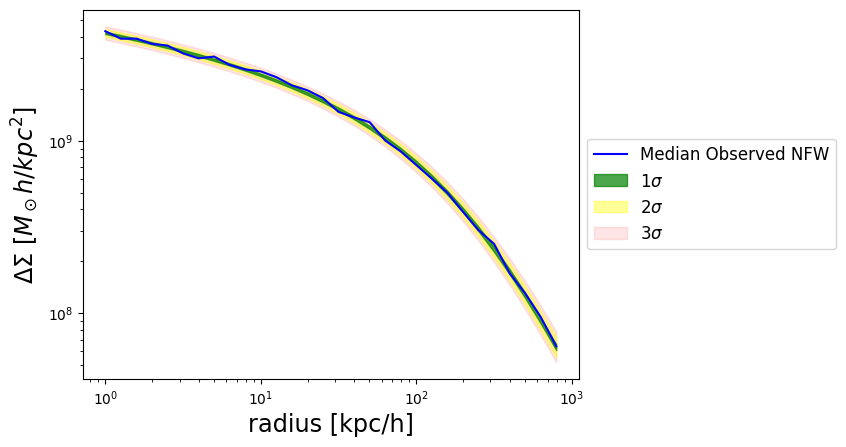

In [251]:
# 3 - Compare with the mean observed NFW profile
# plt.figure()
plt.loglog()
plt.xlabel('radius [kpc/h]', fontsize='xx-large')
plt.ylabel('$\Delta\Sigma$ [$M_\odot h / kpc^2$]', fontsize='xx-large')

sig_1_high = np.percentile(nfw_samples, 68.3, axis=0)
sig_1_low = np.percentile(nfw_samples, 50-(68.3-50), axis=0)
sig_2_high = np.percentile(nfw_samples, 95.5, axis=0)
sig_2_low = np.percentile(nfw_samples, 50-(95.5-50), axis=0)
sig_3_high = np.percentile(nfw_samples, 99.7, axis=0)
sig_3_low = np.percentile(nfw_samples, 50-(99.7-50), axis=0)

plt.fill_between(rbins, sig_3_low, sig_3_high, color='red', alpha=0.1, label='3$\sigma$')
plt.fill_between(rbins, sig_2_low, sig_2_high, color='yellow', alpha=0.4, label='2$\sigma$')
plt.fill_between(rbins, sig_1_low, sig_1_high, color='green', alpha=0.7, label='1$\sigma$')

median_obs = np.median(drawn_nfw_profiles, axis=0)[30:60]
plt.plot(rbins, median_obs, '-', color='blue', label = 'Median Observed NFW')

# reordering the labels 
handles, labels = plt.gca().get_legend_handles_labels() 
# specify order 
order = [3, 2, 1, 0] 
# pass handle & labels lists along with order as below 
plt.legend([handles[i] for i in order], [labels[i] for i in order], fontsize='large', loc='center left', bbox_to_anchor=(1, 0.5))

plt.savefig('PPC/nfw.pdf', bbox_inches='tight')

0.72σ away from mean


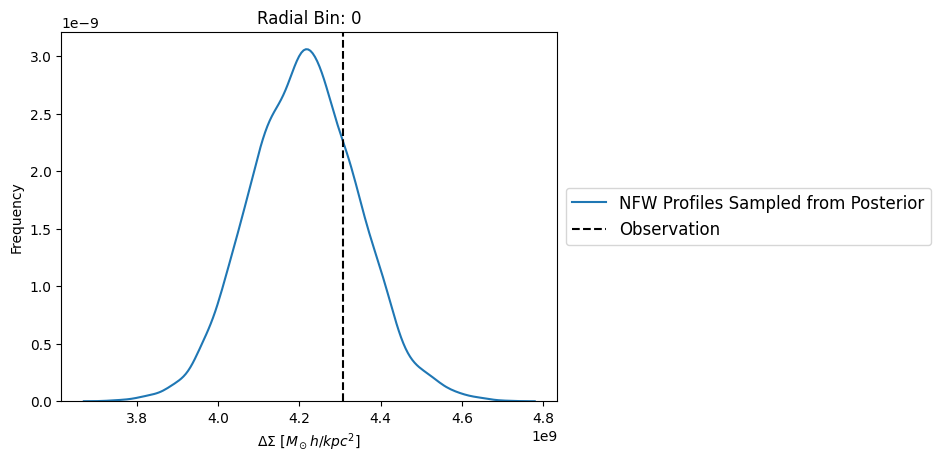

0.11σ away from mean


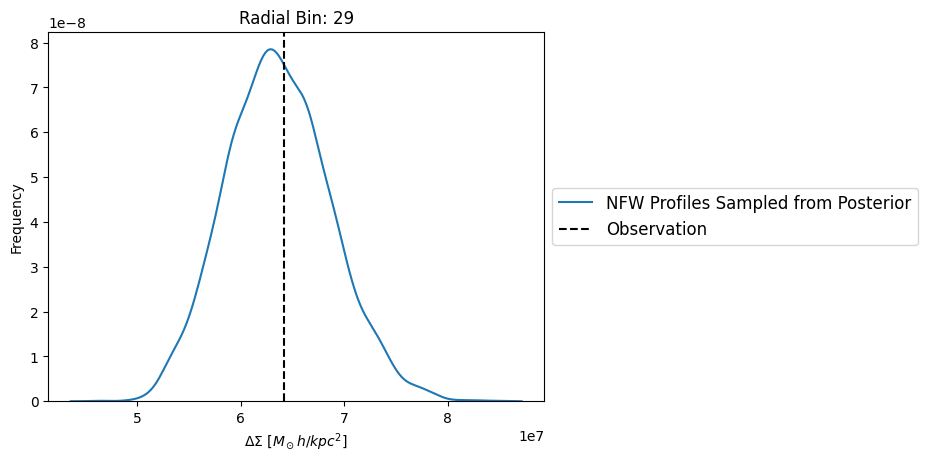

In [253]:
# 4 - For a given radial bin, compare the delta sigma values from observation vs from the generated values
rbin = 0

sns.kdeplot(nfw_samples[:,rbin], label='NFW Profiles Sampled from Posterior')
plt.xlabel('$\Delta\Sigma$ [$M_\odot h / kpc^2$]')
plt.ylabel('Frequency')
plt.axvline(median_obs[rbin], color='k', linestyle='--', label='Observation')
plt.legend(fontsize='large', loc='center left', bbox_to_anchor=(1, 0.5))
plt.title(f'Radial Bin: {rbin}')
plt.savefig(f'PPC/rbin_{rbin}.pdf', bbox_inches='tight')
print(f'{abs(median_obs[rbin]-np.mean(nfw_samples[:,rbin]))/np.std(nfw_samples[:,rbin]):.2f}σ away from mean')
plt.show()

# Repeat with a different radial bin
rbin = 29

sns.kdeplot(nfw_samples[:,rbin], label='NFW Profiles Sampled from Posterior')
plt.xlabel('$\Delta\Sigma$ [$M_\odot h / kpc^2$]')
plt.ylabel('Frequency')
plt.axvline(median_obs[rbin], color='k', linestyle='--', label='Observation')
plt.legend(fontsize='large', loc='center left', bbox_to_anchor=(1, 0.5))
plt.title(f'Radial Bin: {rbin}')
plt.savefig(f'PPC/rbin_{rbin}.pdf', bbox_inches='tight')
print(f'{abs(median_obs[rbin]-np.mean(nfw_samples[:,rbin]))/np.std(nfw_samples[:,rbin]):.2f}σ away from mean')
plt.show()

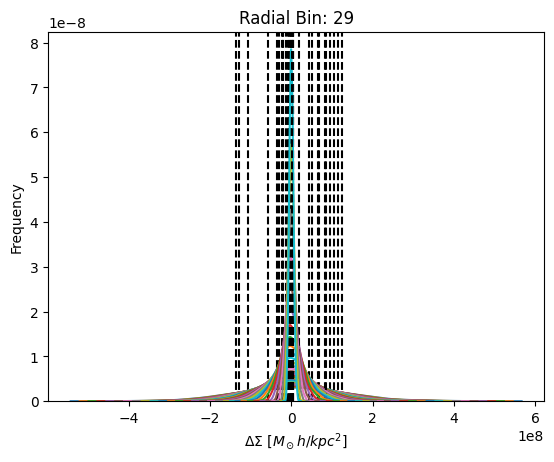

In [254]:
# NORMALIZED

# 4 - For a given radial bin, compare the delta sigma values from observation vs from the generated values
nfw_samples_norm = nfw_samples - np.mean(nfw_samples, axis=0)
sigmas_diff = []
for rbin in range(30):
    # sns.kdeplot(nfw_samples[:,rbin], label='NFW Profiles Sampled from Posterior')
    sns.kdeplot(nfw_samples_norm[:,rbin])#, label='NFW Profiles Sampled from Posterior (r=0)')
    plt.xlabel('$\Delta\Sigma$ [$M_\odot h / kpc^2$]')
    plt.ylabel('Frequency')
    plt.axvline(median_obs[rbin]-np.mean(nfw_samples, axis=0)[rbin], color='k', linestyle='--', label='Observation')
    # plt.legend(fontsize='large', loc='center left', bbox_to_anchor=(1, 0.5))
    plt.title(f'Radial Bin: {rbin}')
    # plt.savefig(f'PPC/rbin_{rbin}.pdf', bbox_inches='tight')
    # print(f'Radial bin {rbin}: {(median_obs[rbin]-np.mean(nfw_samples[:,rbin]))/np.std(nfw_samples[:,rbin]):.2f}σ from mean')
    sigmas_diff.append((median_obs[rbin]-np.mean(nfw_samples[:,rbin]))/np.std(nfw_samples[:,rbin]))
    # plt.show()

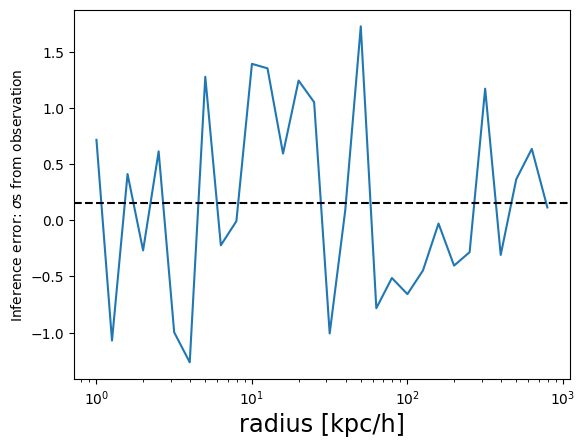

In [255]:
plt.plot(rbins, sigmas_diff)
plt.xscale('log')
plt.axhline(np.mean(sigmas_diff), color='k', linestyle='--')
# plt.xlabel('Radial Bin')
plt.xlabel('radius [kpc/h]', fontsize='xx-large')
plt.ylabel(r'Inference error: $\sigma$s from observation')
plt.show()